# DeepAFM

## Tutorial Overview

This notebook demonstrates transfer learning of a Multitask(denoising and classification) to HECT.
We will execute both standard weight initialization and transfer learning approaches

### What you'll learn:
1. **AFM Image Generation** - Generate 10,000 synthetic AFM images from PDB data
2. **Dataset Creation** - Build train/val/test datasets in WebDataset format with data augmentation (white noise, translation)
3. **Model Training** - Train a ViT-based Autoencoder on HECT data (30 epochs)
4. **Evaluation** - Compute state-classification accuracy and reconstruction quality (MSE/MAE), and visualize attention rollout.
5. **Transfer Learning** - Fine-tune the pretrained model on HECT data
6. **Transfer Learning Training** - Fine-tune the pretrained model on HECT data (30 epochs)
7. **Transfer Learning Evaluation** - Compute state-classification accuracy and reconstruction quality (MSE/MAE), and visualize attention rollout.

### Specifications:
| Item | Value |
|------|-------|
| **Images** | 10,000 total (train/val/test split) |
| **Image size** | 36×36 pixels |
| **Scale** | 0.8 nm/pixel |
| **Model** | ViT Multi-Task Autoencoder |
| **Encoder** | 12 layers, 512 dim, 8 heads |
| **Decoder** | 8 layers, 256 dim, 4 heads |
| **Classifier** | 2 layers, 512 dim, 8 heads |
| **Task** | Multi-task (classification + denoising) |
| **Loss weights** | cls: 1, recon: 100 |
| **Batch size** | 64 |
| **Estimated time** | ~40 minutes (GPU recommended) |

### Requirements
- GPU is recommended (CPU is supported but slower).
- 2.5 GB disk space for generated data and model outputs.
- Python packages from `requirements.txt`.
- **Zenodo dataset is required**:
  1. Download `18587081.zip` from Zenodo.
  2. Place it in the repository root.
  3. Run `bash setup.sh` to extract data into `data/md_raw/` and pretrained weights into `runs/pretrained_model/`

## Setting

In [1]:
# Get current working directory and add ./src to sys.path
import os
import sys
from pathlib import Path
import torch

cwd = Path.cwd()
src_path = cwd / "src"

if src_path.exists():
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
        print("Inserted src into sys.path")
    else:
        print("src already in sys.path")
        
else:
    print("No src directory found at expected path:", src_path)

Inserted src into sys.path


In [2]:
# Experiment Configuration
from configs.experiment_config import ExperimentConfig
from utils.setup_utils import make_experiment_dirs

# Define experiment configuration
protein_of_project = "HECT"
exp_id = "Tutorial_of_{}".format(protein_of_project)

exp_cfg = ExperimentConfig(
    protein_of_project=protein_of_project,
    exp_id=exp_id, 
    scan_direction="x",
)

description = "DeepAFM tutorial experiment for protein {}".format(protein_of_project)
exp_cfg.description = description

make_experiment_dirs(exp_cfg)  # Create experiment directories


## AFM image Generation

In [3]:
from afm_image_generation.core.afm_image_generator_multiprocess import AFMImageGenerator_Multiprocess
from dataload.split_manager import split_and_move_data

### Configure Generation Parameters

In [4]:
# Make run name and save configuration
exp_cfg.system.run_name = exp_id

# Set SEED
exp_cfg.system.seed = 42 

# PDB file path settings
pdb_name_list = [
    "1D5F_CA_only.pdb", # HECT domain of L-shape(PDB: 1D5F)
    "1ND7_CA_only.pdb", # HECT domain of Reversed T-shape(PDB: 1ND7)
    "3JVZ_CA_only.pdb", # HECT domain of Catalytic conformation(PDB: 3JVZ)
    ]
exp_cfg.data_dir.pdb_path = [
    os.path.join(
    exp_cfg.data_dir.md_dir,
    pdb_name
) for pdb_name in pdb_name_list
]  # List of PDB file paths for AFM image generation

exp_cfg.data_dir.dcd_path = None  # DCD file path (not used in this experiment)
exp_cfg.system.pdb_only = True    # Set to True to use only PDB files for AFM image generation

# AFM Image Generation Settings
# save mode settings
exp_cfg.system.md_load_mode = "coarse"   # "all_atom", "coarse" 
exp_cfg.system.save_mode = "webdataset"  # Options: "hdf5", "tfrecord", "webdataset"
exp_cfg.system.use_gpu_for_afm = False     
exp_cfg.system.device = "cpu"            # use only cpu for AFM image generation

# Set AFM image generation parameters
exp_cfg.afm.random.scan_preset_list = [
    {"scale_x": 0.6, "scale_y": 0.6, "width_px": 36, "height_px": 36}
    ]
exp_cfg.afm.fixed.fixed_width_px = 36        # Set fixed width in pixels for saving AFM images
exp_cfg.afm.fixed.fixed_height_px = 36       # Set fixed height in pixels for saving AFM images

# range -> list
exp_cfg.afm.random.__post_init__()  
exp_cfg.afm.random.pdb_num_list = list(range(1, len(pdb_name_list) + 1)) # Set PDB frame number list (PDB: 1D5F, 1ND7, 3JVZ)

# AFM job settings
exp_cfg.afm.job.total_images = 10000              # Number of AFM images to generate
exp_cfg.afm.job.processes = 32                    # Number of processes for AFM image generation
exp_cfg.afm.job.chunk_size = 1000                 # Chunk size for saving AFM image
exp_cfg.afm.job.vectorized = False                # execute AFM image generation in vectorized mode
exp_cfg.afm.job.output_mode = [                   # Output mode for AFM image generation
    "distorted",  # Distorted AFM image accounting for asynchronous measurement times
    "ideal",      # Instantaneous AFM image
    "config"      # Parameters used for image generation
]

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file


### Generate AFM Images and Split Dataset

In [5]:
# Initialize AFM Image Generator with Multiprocessing
generator = AFMImageGenerator_Multiprocess(exp_cfg)

# Set up and run AFM image generation
generator.setup()
generator.run_parallel_process()

# shut down the generator after completion
generator.shutdown()

# Split generated data into train/val/test sets
save_mode_to_extension = {
    "hdf5": "hdf5",
    "tfrecord": "tfrecord",
    "webdataset": "tar",
}

split_and_move_data(
    exp_cfg, 
    extension=save_mode_to_extension[exp_cfg.system.save_mode]
    )


AFMInputGenerator: parameter_mode = random
[AFM Multiprocess] Configured for 10000 images using 32 processes with chunk size 1000.
[AFM Multiprocess] Use GPU for AFM: False
[AFM Multiprocess] Save mode set to: webdataset
[AFM Multiprocess] Scan direction: x, Scan unit: line


2026-03-04 18:58:42,288	INFO worker.py:1951 -- Started a local Ray instance.


2026-03-04 18:58:42,465	INFO packaging.py:588 -- Creating a file package for local module '/home/ksatou/2025_DeepAFM_Pytorch/DeepAFM/src'.


2026-03-04 18:58:42,627	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_cb4ee75748022da0.zip' (37.90MiB) to Ray cluster...


2026-03-04 18:58:42,744	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_cb4ee75748022da0.zip'.


...

[WebDataset] Saved chunk → data/Tutorial_of_HECT/afm_generated/42_0007.tar


[WebDataset] Saved chunk → data/Tutorial_of_HECT/afm_generated/42_0008.tar


[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.


[WebDataset] Saved chunk → data/Tutorial_of_HECT/afm_generated/42_0009.tar


[Shutdown] Ray environment closed successfully.


## Data loader

In [6]:
from dataload.webdataset_loader import create_afm_dataloader
from dataload.preprocess import AFMPreprocess

# device settings for data loading and preprocessing
exp_cfg.system.device = "cuda" if torch.cuda.is_available() else "cpu"

# set data load modes
exp_cfg.system.data_load_mode = ["distorted", "ideal", "config"]

# set preprocess and data augmentation 
# add white noise option
exp_cfg.data.add_white_noise = True
exp_cfg.data.noise_std_range = (0.0, 0.3, 0.01)  # Range of noise stddev for augmentation

# translation range in pixels
exp_cfg.data.translation_x_pixel = (-3, 3, 1)    # set translation range in pixels
exp_cfg.data.translation_y_pixel = (-3, 3, 1)    # set translation range in pixels
exp_cfg.data.__post_init__()                    # expand ranges to lists

# scaling option
exp_cfg.data.min_max_scaling = True

# pdb number to state mapping
exp_cfg.data.pdb_num_to_state = True            # enable pdb_num to state mapping
exp_cfg.train.batch_size = 64                   # Batch size for training

# set pdb_num-to-state mapping mode ("unsupervised" or "custom")
# if "unsupervised", map PDB numbers to states based on unsupervised learning results
# details in src/dataload/preprocess.py::_pdb_num_to_state
# custom mode allows users to specify their own mapping from PDB frame numbers to state labels, 
# which is useful for tutorial purposes or when the mapping is known a priori.

exp_cfg.data.pdb_num_to_state_mapping_mode = "custom"  

# for custom mapping mode, specify the mapping from pdb frame number to state label
exp_cfg.data.custom_mapping = {
    1: 0,   # PDB frame number 1 -> state 0 (L-shape, PDB: 1D5F)
    2: 1,   # PDB frame number 2 -> state 1 (Reversed T-shape, PDB: 1ND7)
    3: 2    # PDB frame number 3 -> state 2 (Catalytic conformation, PDB: 3JVZ)
}

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file

train_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.train_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    shuffle=True
    )

val_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.val_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    shuffle=False
    )

# preprocessor for visualization (no min-max scaling)
preprocessor = AFMPreprocess(
    exp_cfg=exp_cfg,
    add_white_noise=False,
    translate=False,
    min_max_scaling=False,
    pdb_num_to_state=True,
    )

test_dataloader_for_vis = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.test_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    preprocessor=preprocessor,
    shuffle=False
    )

# preprocessor for visualization (no min-max scaling)
preprocessor = AFMPreprocess(
    exp_cfg=exp_cfg,
    add_white_noise=False,
    translate=False,
    min_max_scaling=True,
    pdb_num_to_state=True,
    )

test_dataloader_for_eval = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.test_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    preprocessor=preprocessor,
    shuffle=False
    )

## Training

In [7]:
from configs.nn_config import ViTMultiTaskAutoEncoderConfig
from models.ViT_MultiTask_AutoEncoder import ViTMultiTaskAutoEncoder
from builders.loss_builder import build_loss
from builders.metrics_builder import build_metrics  
from builders.optimizer_builder import build_optimizer
from builders.scheduler_builder import build_scheduler
from training.trainer import ModelTrainer

In [8]:
# Training ViT for DeepAFM
exp_cfg.system.run_name = exp_id
exp_cfg.system.nn_dtype = "fp32" 
exp_cfg.system.save_interval = 30 # Save model every 30 epochs 
exp_cfg.train.use_amp = True      # If use GPU with AMP, set to True is recommended

# Set ViT model parameters
exp_cfg.model = ViTMultiTaskAutoEncoderConfig()    # Use ViTMultiTaskAutoEncoderConfig for AE
exp_cfg.model.image_size = 36                      # Image size for ViT
exp_cfg.model.patch_size = 3                       # Patch size for ViT
exp_cfg.model.enc_embed_dim = 512                  # Embedding dimension for ViT
exp_cfg.model.enc_depth = 12                        # Depth of ViT model
exp_cfg.model.enc_num_heads = 8                    # Number of attention heads for ViT
exp_cfg.model.enc_mlp_ratio = 4                    # MLP ratio for ViT

exp_cfg.model.dec_embed_dim = 256                  # Embedding dimension for ViT
exp_cfg.model.dec_depth = 8                        # Depth of ViT model
exp_cfg.model.dec_num_heads = 4                    # Number of attention heads for ViT
exp_cfg.model.dec_mlp_ratio = 4                    # MLP ratio for ViT

exp_cfg.model.class_depth = 2                      # Depth of classifier head
exp_cfg.model.num_classes = 3                      # Number of classes for classification task

# scheduler settings
exp_cfg.train.scheduler = "cosine"                 # Learning rate scheduler type

# dataload settings
exp_cfg.data.num_workers = 32                       # Number of worker processes for data loading
exp_cfg.data.prefetch_size = 1                     # Prefetch size for data loading

# Set training parameters for ViT
exp_cfg.train.epochs = 30                         # Number of training epochs
# task mode
exp_cfg.train.task_mode = "multitask"             # "denoise" or "multitask"
# loss weights for multitask
exp_cfg.train.recons_loss_type = "mse"            # for denoise/reconstruction task: "mse", "l1", "huber"
exp_cfg.train.weight_cls = 1                      # weight for classification loss   
exp_cfg.train.weight_recon = 100                  # weight for reconstruction(denoise) loss

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file


In [9]:
#  --- Training ---
model = ViTMultiTaskAutoEncoder.from_config(exp_cfg)

loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)
optimizer = build_optimizer(exp_cfg, model)
scheduler = build_scheduler(exp_cfg, optimizer)

trainer = ModelTrainer(
    exp_cfg=exp_cfg, 
    model=model,
    loss_fn=loss_fn,
    loss_weights=loss_weights,
    metrics=metrics,
    optimizer=optimizer,
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    scheduler=scheduler
    )

trainer.fit()

[Trainer] No checkpoints found, start from scratch.
[Trainer] Starting training for 30 epochs
[Trainer] Starting training from epoch 1


 >> New Best Model found! Val Loss: 1.937216


[Checkpoint] Saved best model: runs/Tutorial_of_HECT/checkpoints/best_model.pt
Epoch 1 | LR: 9.97e-05 | train_ideal_mae: inf | train_ideal_mse: 0.1228 | train_loss: 13.4191 | train_loss_ideal: 0.1228 | train_loss_state: 1.1347 | train_state_acc: 0.3518 | val_ideal_mae: 0.0405 | val_ideal_mse: 0.0084 | val_loss: 1.9372 | val_loss_ideal: 0.0084 | val_loss_state: 1.0971 | val_state_acc: 0.3340


 >> New Best Model found! Val Loss: 1.852008


[Checkpoint] Saved best model: runs/Tutorial_of_HECT/checkpoints/best_model.pt
Epoch 2 | LR: 9.89e-05 | train_ideal_mae: 0.0616 | train_ideal_mse: 0.0100 | train_loss: 2.1088 | train_loss_ideal: 0.0100 | train_loss_state: 1.1059 | train_state_acc: 0.3489 | val_ideal_mae: 0.0380 | val_ideal_mse: 0.0077 | val_loss: 1.8520 | val_loss_ideal: 0.0077 | val_loss_state: 1.0860 | val_state_acc: 0.3670


...

Epoch 30 | LR: 0.00e+00 | train_ideal_mae: 0.0342 | train_ideal_mse: 0.0051 | train_loss: 1.4090 | train_loss_ideal: 0.0051 | train_loss_state: 0.9015 | train_state_acc: 0.5576 | val_ideal_mae: 0.0277 | val_ideal_mse: 0.0047 | val_loss: 1.3635 | val_loss_ideal: 0.0047 | val_loss_state: 0.8886 | val_state_acc: 0.5610


[Checkpoint] Saved: runs/Tutorial_of_HECT/checkpoints/model_epoch30.pt
[Logger] Saved plot: curve_Learning_Rate.png


[Logger] Saved plot: curve_loss.png
[Logger] Saved plot: curve_loss_ideal.png


[Logger] Saved plot: curve_loss_state.png
[Logger] Saved plot: curve_ideal_mae.png


[Logger] Saved plot: curve_ideal_mse.png
[Logger] Saved plot: curve_state_acc.png


## Evaluation

In [10]:
from evaluation.evaluater import Evaluator

In [11]:
# --- Evaluation ---
model = ViTMultiTaskAutoEncoder.from_config(exp_cfg)
evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_eval
    )
# Build loss and metrics for evaluation
loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)

#evaluator.load_latest_checkpoint()
evaluator.load_best_checkpoint()

# Compute loss and metrics
results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
    )

print("ACCURACY:", results['test_state_acc'])
print("MSE:", results['test_ideal_mse'])
print("MAE:", results['test_ideal_mae'])

# Compute confusion matrix
evaluator.compute_confusion_matrix()

[Evaluator] Loading latest checkpoint: runs/Tutorial_of_HECT/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_HECT/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 28


[Evaluator] Saved evaluation results to runs/Tutorial_of_HECT/evaluation_results/evaluation_results.txt
ACCURACY: 0.596
MSE: 0.004594112396240234
MAE: 0.025880859375


[Evaluator] Saved confusion matrix to runs/Tutorial_of_HECT/evaluation_results/confusion_matrix.npy


[Evaluator] Saved confusion matrix to runs/Tutorial_of_HECT/evaluation_results/confusion_matrix.pdf


[Evaluator] Loading latest checkpoint: runs/Tutorial_of_HECT/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_HECT/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 28


[Evaluator] Saved evaluation results to runs/Tutorial_of_HECT/evaluation_results/evaluation_results.txt
{'test_loss': 1.3212642822265626, 'test_loss_ideal': 0.004594112396240234, 'test_loss_state': 0.86185302734375, 'test_ideal_mae': 0.025880859375, 'test_ideal_mse': 0.004594112396240234, 'test_state_acc': 0.596}


--- Physical Evaluation Results (nm) ---
avg_physical_mse: 0.1297
avg_physical_mae: 0.1362
total_samples: 1000.0000
[Evaluator] Saved physical results to runs/Tutorial_of_HECT/evaluation_results/evaluation_results.txt


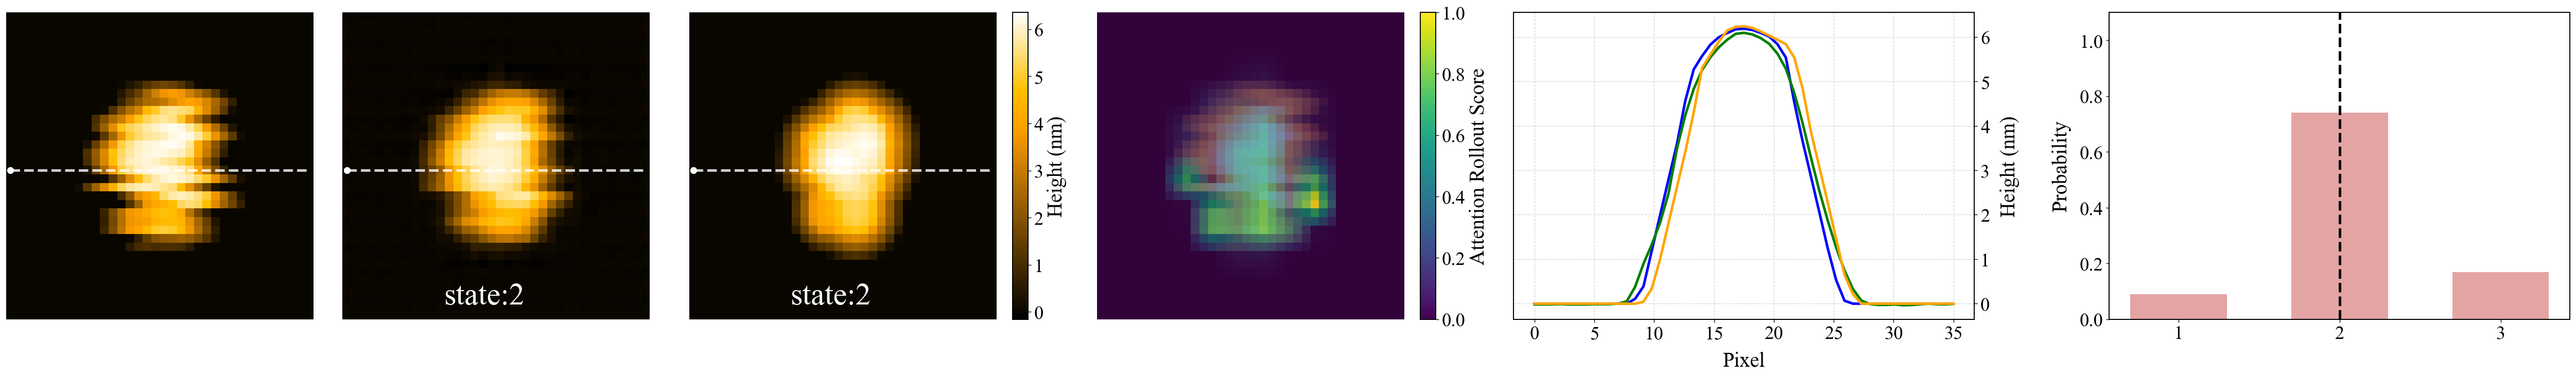

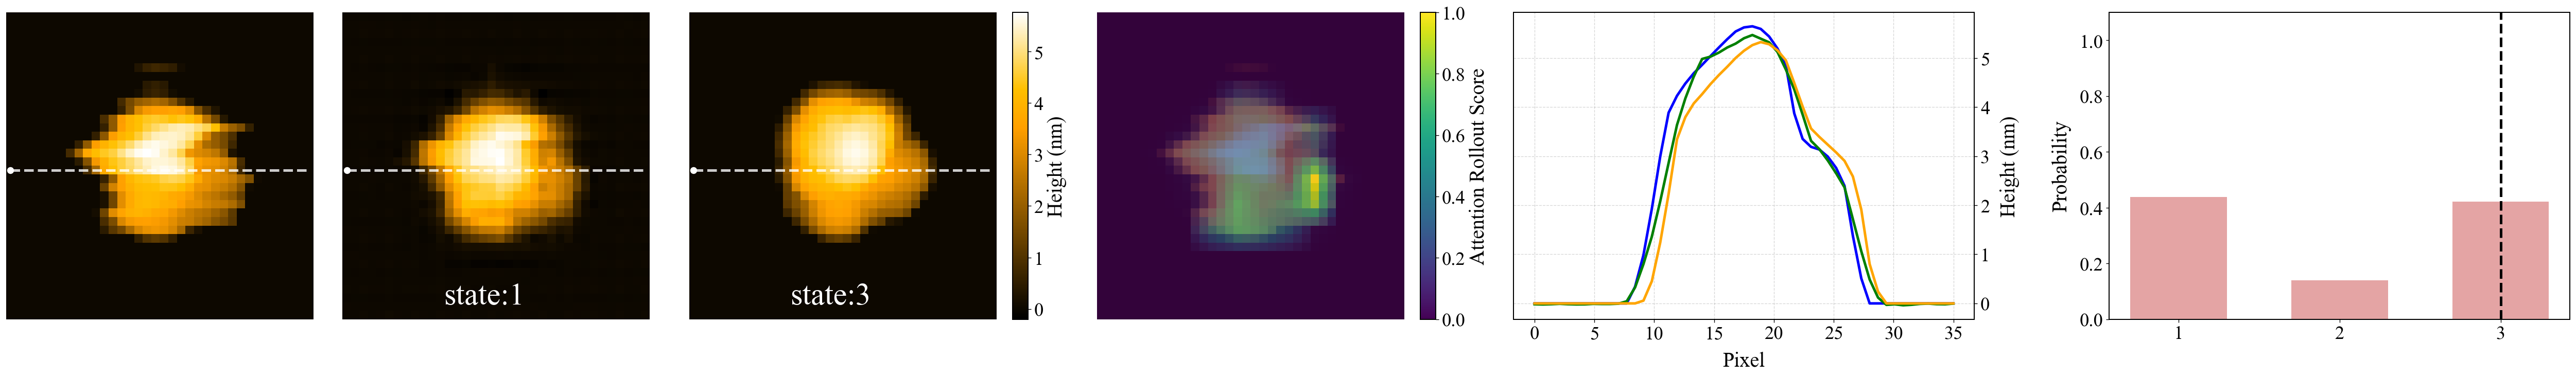

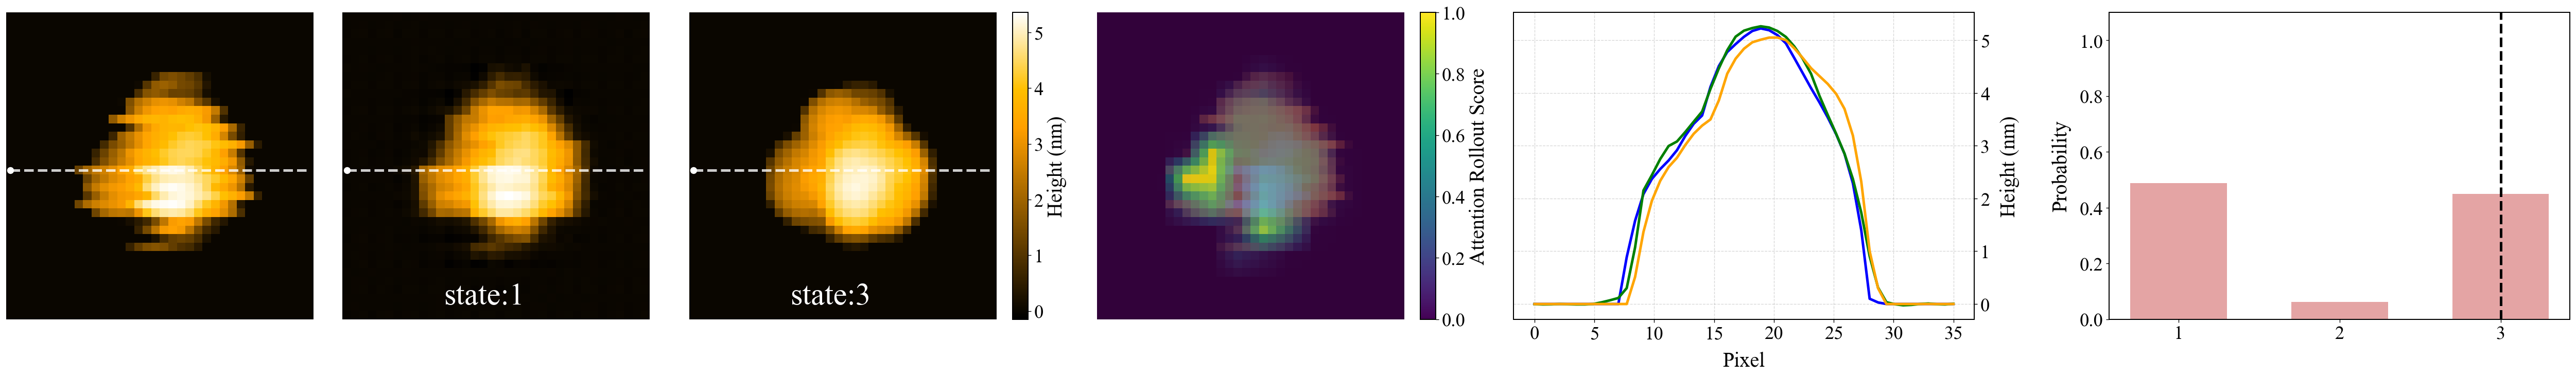

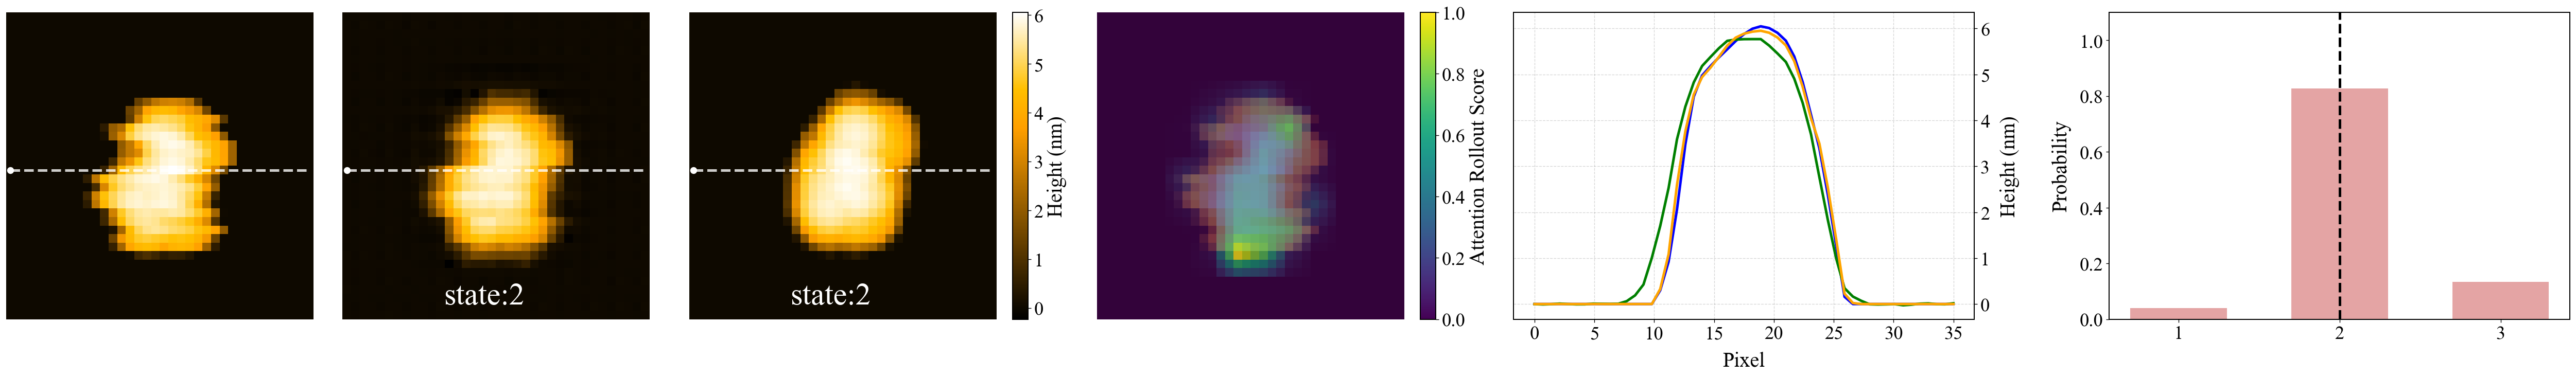

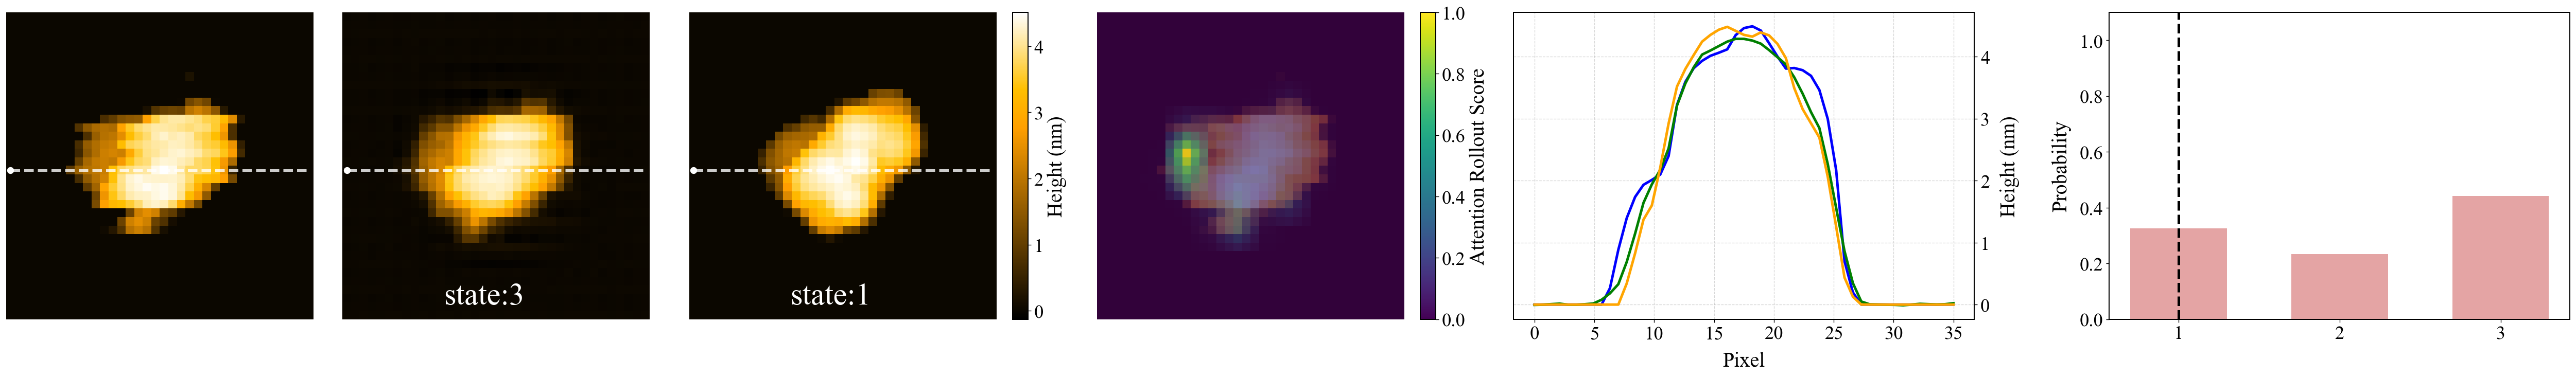

[Evaluator] Saved metrics log to runs/Tutorial_of_HECT/evaluation_results/multitask_comprehensive/evaluation_metrics.csv (Total 5 samples)


In [12]:
# Visualization
IMG_NUMS = 5
IMAGE_SIZE = exp_cfg.model.image_size
ATTN_ANA_MODE = "classification_only"

evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_eval
)

evaluator.load_best_checkpoint()

results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
)

print(results)

# MAE MSE (not scaled)
evaluator.compute_physical_metrics(
    dataloader=test_dataloader_for_vis # not scaled is needed for physical metrics
)

# Comprehensive Multi-Task Visualization
evaluator.visualize_multitask_comprehensive(
    dataloader=test_dataloader_for_vis,
    num_samples=IMG_NUMS,
    start=(int(IMAGE_SIZE/2), 0),
    angle_deg=0,
    analyze_task=ATTN_ANA_MODE,
    save=False,
    )

## Transfer Learning

In [13]:
from configs.nn_config import ViTMultiTaskAutoEncoderConfig
from models.ViT_MultiTask_AutoEncoder import ViTMultiTaskAutoEncoder
from models.factory import create_model_from_pretrained
from builders.loss_builder import build_loss
from builders.metrics_builder import build_metrics  
from builders.optimizer_builder import build_optimizer
from builders.scheduler_builder import build_scheduler
from training.trainer import ModelTrainer

In [14]:
# Define experiment configuration
exp_id = "Tutorial_of_{}_transfer".format(protein_of_project)

exp_cfg = ExperimentConfig(
    protein_of_project=protein_of_project,
    exp_id=exp_id, 
    scan_direction="x",
)

description = "DeepAFM tutorial experiment for protein {}".format(protein_of_project)
exp_cfg.description = description

make_experiment_dirs(exp_cfg)  # Create experiment directories


In [15]:
pretrained_dir = os.path.join(cwd, "runs", "pretrained_model")

pretrained_model_path = os.path.join(
    pretrained_dir, 
    "checkpoints", 
    "best_model.pt"
)

config_path = os.path.join(
    pretrained_dir, 
    "config.yaml"
)

exp_cfg.system.save_interval = 30 # Save model every 30 epochs 
exp_cfg.train.use_amp = True      # If use GPU with AMP, set to True is recommended

# scheduler settings
exp_cfg.train.scheduler = "cosine"                # Learning rate scheduler type

# dataload settings
exp_cfg.data.num_workers = 32                     # Number of worker processes for data loading
exp_cfg.data.prefetch_size = 1                    # Prefetch size for data loading

# Set training parameters for ViT
exp_cfg.train.epochs = 30                         # Number of training epochs
# task mode
exp_cfg.train.task_mode = "multitask"             # "denoise" or "multitask"
exp_cfg.train.recons_loss_type = "mse"            # for denoise/reconstruction task: "mse", "l1", "huber"

exp_cfg.train.weight_cls = 1                      # weight for classification loss   
exp_cfg.train.weight_recon = 100                  # weight for reconstruction(denoise) loss

# model
exp_cfg.model.image_size = 36                     # Image size for ViT
exp_cfg.model.patch_size = 3                      # Patch size for ViT
exp_cfg.model.num_classes = 3                     # Set number of classes for classification head

# Create model from pretrained weights and configuration
model = create_model_from_pretrained(
    exp_cfg=exp_cfg,
    checkpoint_path=pretrained_model_path,
    config_path=config_path,
)

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file


[Model] Loading pretrained weights with adaptation from: runs/pretrained_model/checkpoints/best_model.pt


## Transfer Learning

In [16]:
#  --- Training ---
loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)
optimizer = build_optimizer(exp_cfg, model)
scheduler = build_scheduler(exp_cfg, optimizer)

trainer = ModelTrainer(
    exp_cfg=exp_cfg, 
    model=model,
    loss_fn=loss_fn,
    loss_weights=loss_weights,
    metrics=metrics,
    optimizer=optimizer,
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    scheduler=scheduler
    )

trainer.fit()

[Trainer] No checkpoints found, start from scratch.
[Trainer] Starting training for 30 epochs
[Trainer] Starting training from epoch 1


 >> New Best Model found! Val Loss: 0.313812


[Checkpoint] Saved best model: runs/Tutorial_of_HECT_transfer/checkpoints/best_model.pt
Epoch 1 | LR: 9.97e-05 | train_ideal_mae: 0.0184 | train_ideal_mse: 0.0028 | train_loss: 0.6527 | train_loss_ideal: 0.0028 | train_loss_state: 0.3748 | train_state_acc: 0.8695 | val_ideal_mae: 0.0160 | val_ideal_mse: 0.0022 | val_loss: 0.3138 | val_loss_ideal: 0.0022 | val_loss_state: 0.0927 | val_state_acc: 0.9740


 >> New Best Model found! Val Loss: 0.236937


[Checkpoint] Saved best model: runs/Tutorial_of_HECT_transfer/checkpoints/best_model.pt
Epoch 2 | LR: 9.89e-05 | train_ideal_mae: 0.0158 | train_ideal_mse: 0.0021 | train_loss: 0.2759 | train_loss_ideal: 0.0021 | train_loss_state: 0.0629 | train_state_acc: 0.9805 | val_ideal_mae: 0.0150 | val_ideal_mse: 0.0019 | val_loss: 0.2369 | val_loss_ideal: 0.0019 | val_loss_state: 0.0479 | val_state_acc: 0.9870


...

Epoch 30 | LR: 0.00e+00 | train_ideal_mae: 0.0108 | train_ideal_mse: 0.0010 | train_loss: 0.1012 | train_loss_ideal: 0.0010 | train_loss_state: 0.0020 | train_state_acc: 0.9994 | val_ideal_mae: 0.0104 | val_ideal_mse: 0.0010 | val_loss: 0.1090 | val_loss_ideal: 0.0010 | val_loss_state: 0.0061 | val_state_acc: 0.9990


[Checkpoint] Saved: runs/Tutorial_of_HECT_transfer/checkpoints/model_epoch30.pt
[Logger] Saved plot: curve_Learning_Rate.png


[Logger] Saved plot: curve_loss.png
[Logger] Saved plot: curve_loss_ideal.png


[Logger] Saved plot: curve_loss_state.png
[Logger] Saved plot: curve_ideal_mae.png


[Logger] Saved plot: curve_ideal_mse.png
[Logger] Saved plot: curve_state_acc.png


## Transfer Learnin Evaluation

In [17]:
from evaluation.evaluater import Evaluator
from dataload.preprocess import AFMPreprocess

In [18]:
# --- Evaluation ---
evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_eval
    )
# Build loss and metrics for evaluation
loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)

#evaluator.load_latest_checkpoint()
evaluator.load_best_checkpoint()

# Compute loss and metrics
results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
    )

print("ACCURACY:", results['test_state_acc'])
print("MSE:", results['test_ideal_mse'])
print("MAE:", results['test_ideal_mae'])

# Compute confusion matrix
evaluator.compute_confusion_matrix()

[Evaluator] Loading latest checkpoint: runs/Tutorial_of_HECT_transfer/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_HECT_transfer/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 28


[Evaluator] Saved evaluation results to runs/Tutorial_of_HECT_transfer/evaluation_results/evaluation_results.txt
ACCURACY: 0.999
MSE: 0.0009742156267166138
MAE: 0.010129150390625


[Evaluator] Saved confusion matrix to runs/Tutorial_of_HECT_transfer/evaluation_results/confusion_matrix.npy


[Evaluator] Saved confusion matrix to runs/Tutorial_of_HECT_transfer/evaluation_results/confusion_matrix.pdf


[Evaluator] Loading latest checkpoint: runs/Tutorial_of_HECT_transfer/checkpoints/model_epoch30.pt


[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_HECT_transfer/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 28


--- Physical Evaluation Results (nm) ---
avg_physical_mse: 0.0269
avg_physical_mae: 0.0532
total_samples: 1000.0000
[Evaluator] Saved physical results to runs/Tutorial_of_HECT_transfer/evaluation_results/evaluation_results.txt


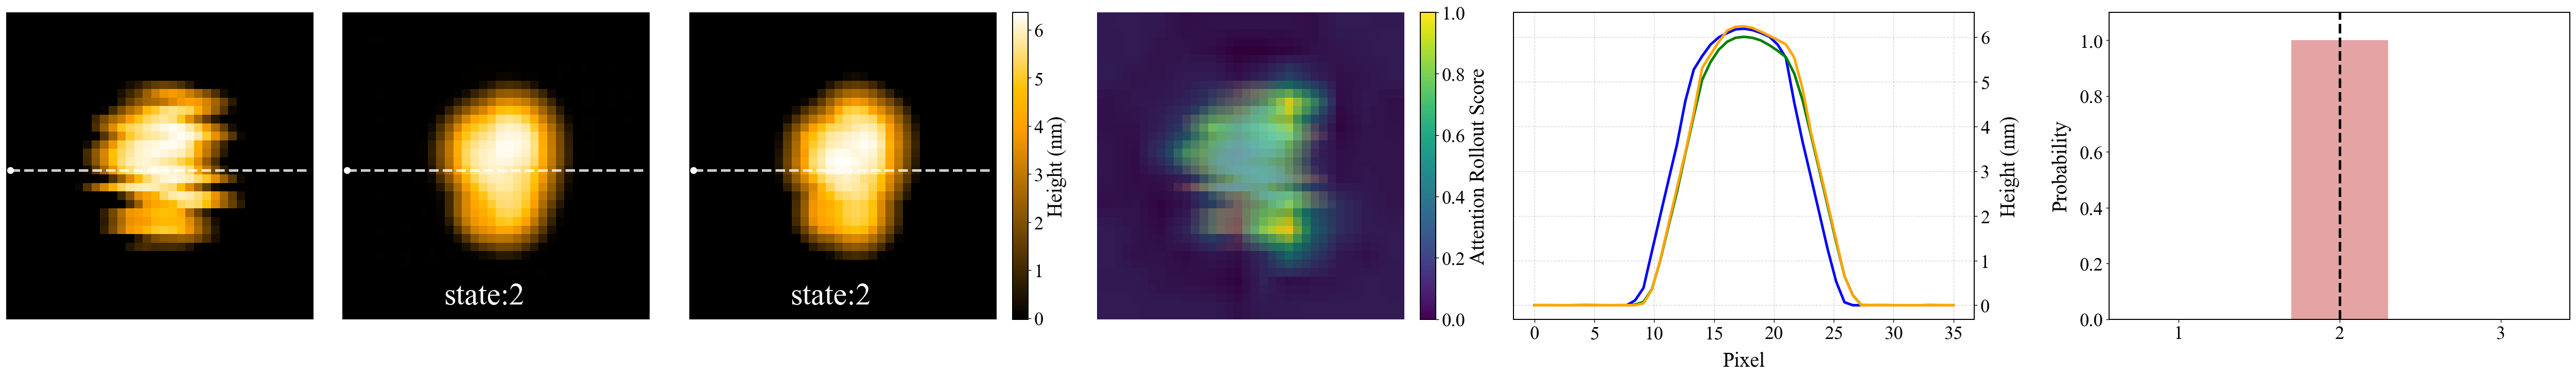

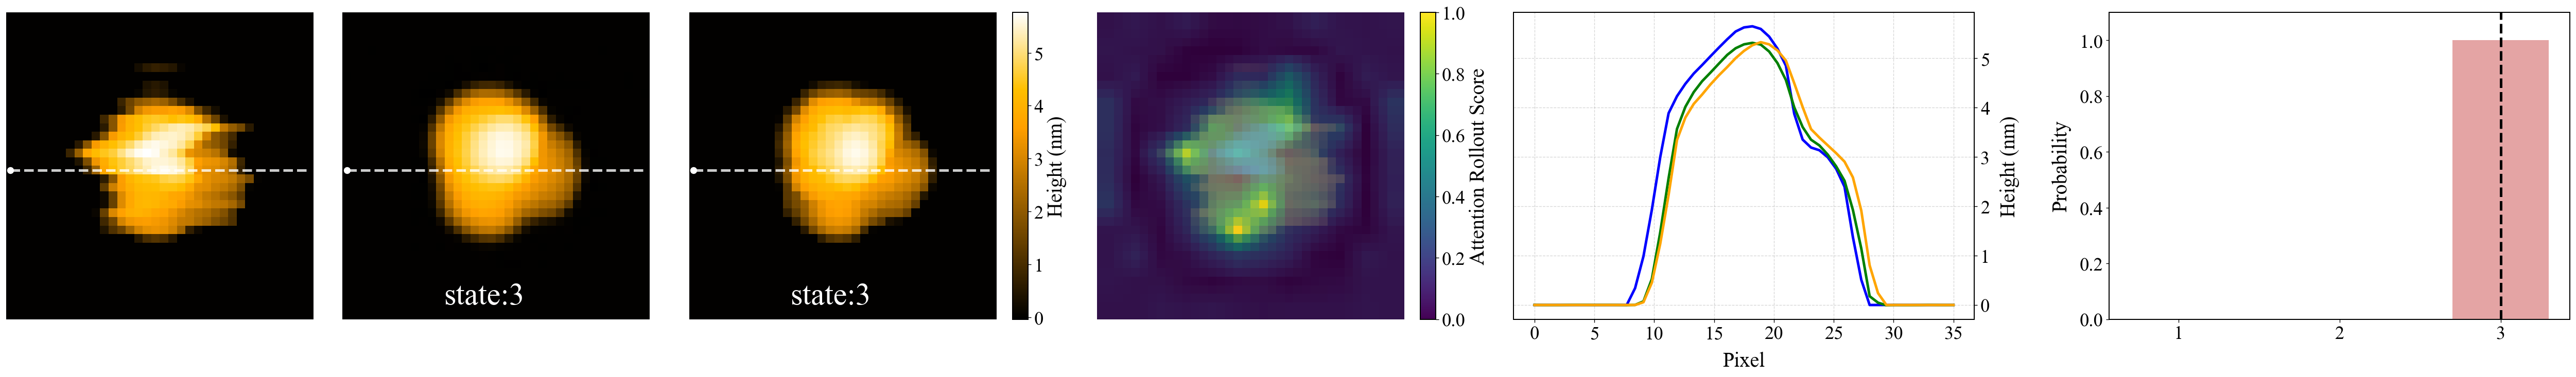

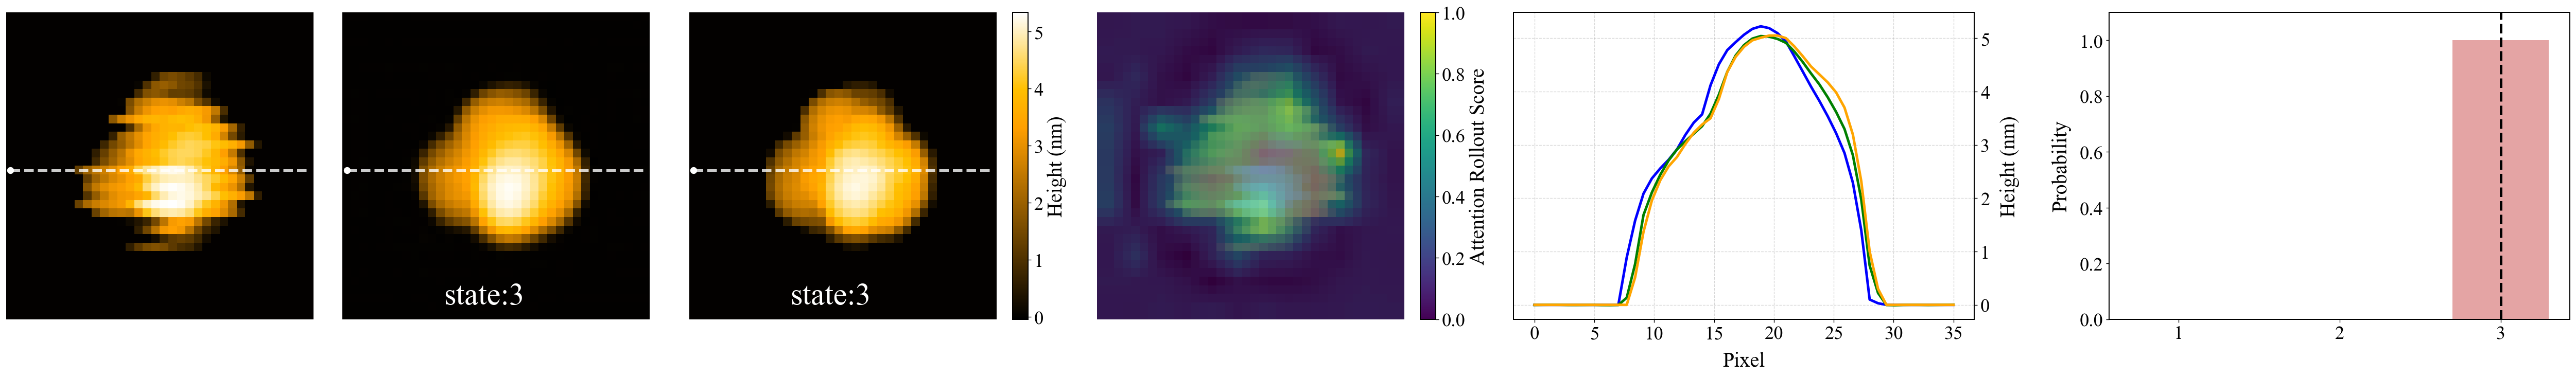

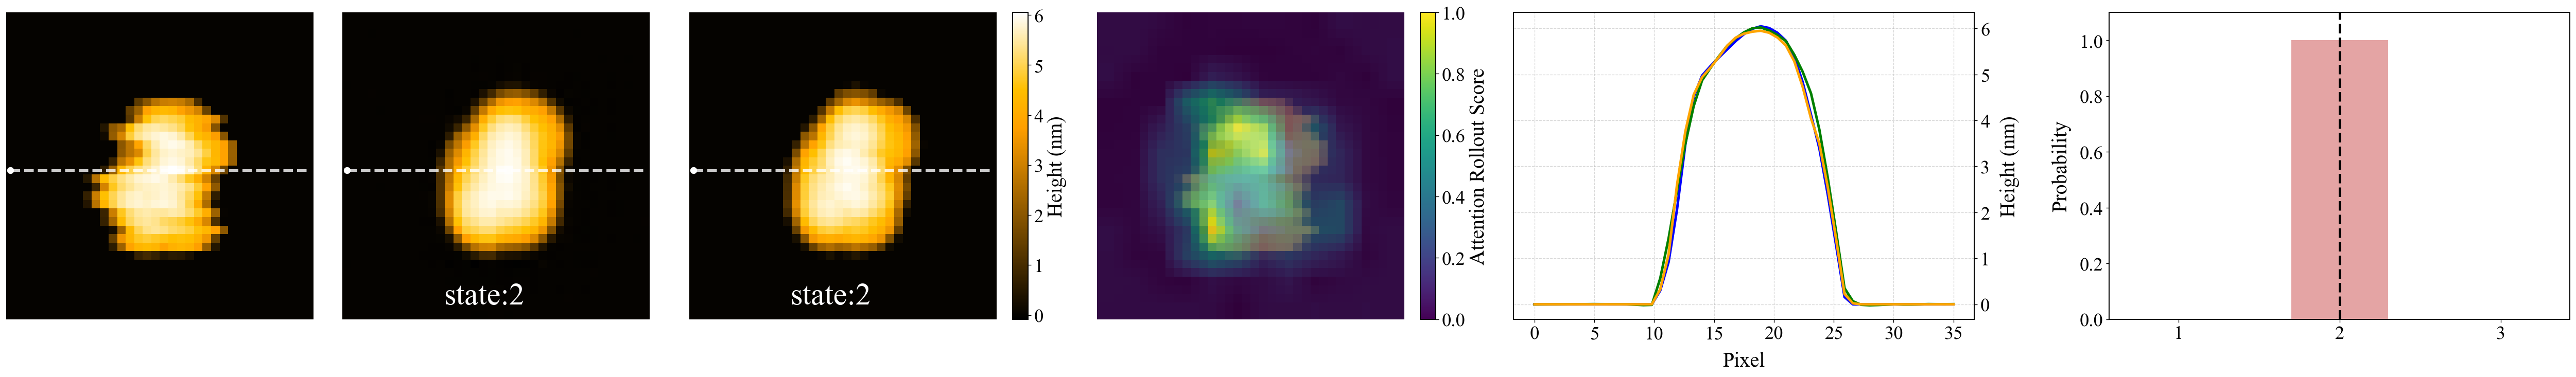

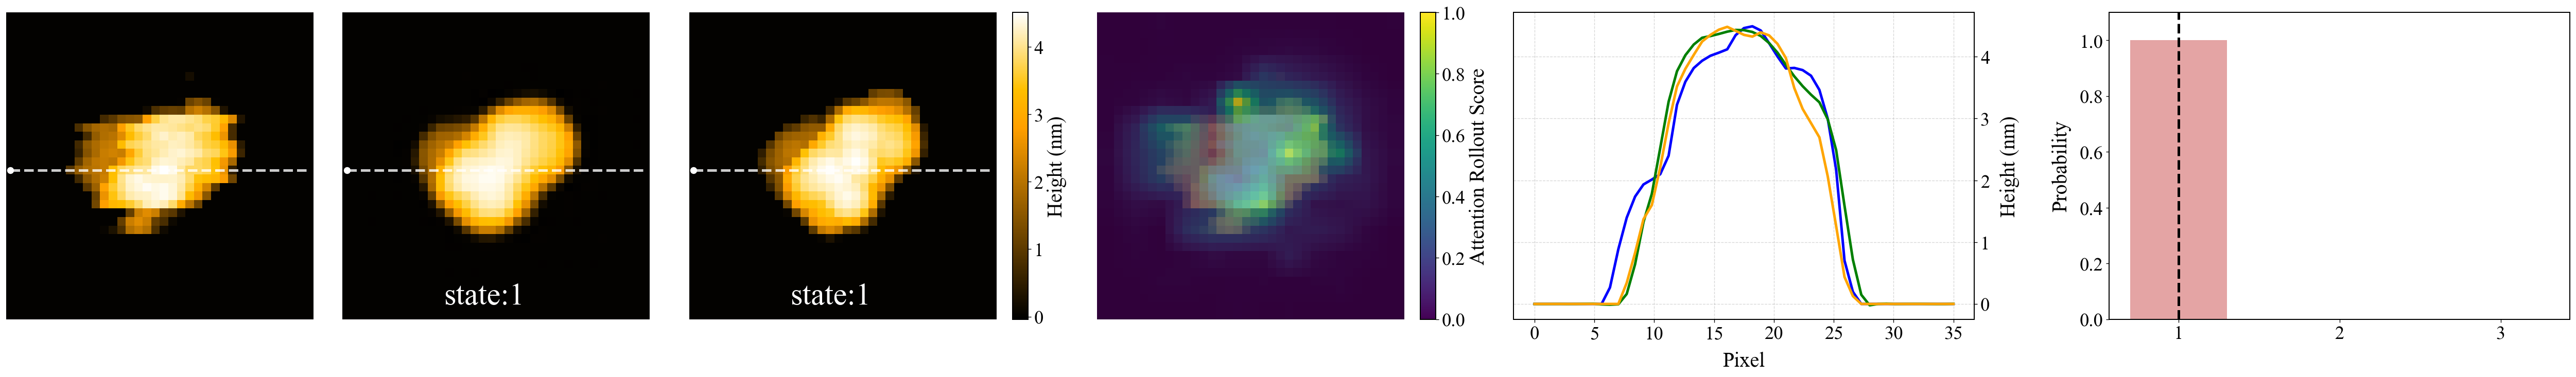

[Evaluator] Saved metrics log to runs/Tutorial_of_HECT_transfer/evaluation_results/multitask_comprehensive/evaluation_metrics.csv (Total 5 samples)


In [19]:
# Visualization
IMG_NUMS = 5
IMAGE_SIZE = exp_cfg.model.image_size
ATTN_ANA_MODE = "classification_only"   # attention analysis mode: # "classification" or "classification_only" 

evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader_for_vis
    )

evaluator.load_best_checkpoint()

# MAE MSE (not scaled)
evaluator.compute_physical_metrics(
    dataloader=test_dataloader_for_vis # not scaled is needed for physical metrics
)

# Comprehensive Multi-Task Visualization
evaluator.visualize_multitask_comprehensive(
    dataloader=test_dataloader_for_vis,
    num_samples=IMG_NUMS,
    start=(int(IMAGE_SIZE/2), 0),
    angle_deg=0,
    analyze_task=ATTN_ANA_MODE,
    save=False,
    )
